# 02 — Preprocessing
**Employee Feedback Intelligence Platform**

This notebook covers:
1. Load raw data
2. Drop duplicates
3. Handle missing values
4. Combine `pros` + `cons` into one `text` field
5. Clean text (lowercase, strip HTML/URLs/punctuation)
6. Tokenization
7. Stopword removal
8. Lemmatization
9. Map ratings → sentiment labels
10. Save cleaned dataset to `data/processed/cleaned.csv`

## 0. Imports & Config

In [1]:
import os, sys, warnings, re
warnings.filterwarnings('ignore')
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for pkg in ['punkt', 'stopwords', 'wordnet', 'omw-1.4', 'punkt_tab']:
    nltk.download(pkg, quiet=True)

print('✅ Ready')

✅ Ready


In [3]:
df = pd.read_csv("../data/glassdoor_reviews.csv")
print(f'Loaded : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Loaded : 838,566 rows × 18 columns


,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in...,"Very low salary, poor working conditions, very..."


## 2. Drop Duplicates

In [4]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after  = len(df)

print(f'Rows before : {before:,}')
print(f'Rows after  : {after:,}')
print(f'Dropped     : {before - after:,} duplicates')

Rows before : 838,566
Rows after  : 805,051
Dropped     : 33,515 duplicates


## 3. Handle Missing Values

In [5]:
# Before
print('Missing values BEFORE:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values BEFORE:
location               285095
work_life_balance      144060
culture_values         183364
diversity_inclusion    674160
career_opp             141726
comp_benefits          144242
senior_mgmt            149804
headline                 2451
pros                        2
cons                       13
dtype: int64


In [ ]:
# Fill text columns with empty string
text_cols = ['pros', 'cons', 'advice-to-mgmt'] 
for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna('')

# Drop rows where rating is missing (we need it for labels)
rating_col = 'overall_rating'
df[rating_col] = pd.to_numeric(df[rating_col], errors='coerce')
before = len(df)
df = df.dropna(subset=[rating_col]).reset_index(drop=True)
print(f'Dropped {before - len(df):,} rows with missing ratings')

# Clip ratings to valid range 1–5
df[rating_col] = df[rating_col].clip(1, 5)

print('\nMissing values AFTER:')
remaining = df.isnull().sum()[df.isnull().sum() > 0]
print(remaining if not remaining.empty else '  None ✅')

Dropped 0 rows with missing ratings

Missing values AFTER:
location               285095
work_life_balance      144060
culture_values         183364
diversity_inclusion    674160
career_opp             141726
comp_benefits          144242
senior_mgmt            149804
headline                 2451
dtype: int64


In [8]:
df['text'] = (df['pros'].fillna('') + ' ' + df['cons'].fillna('')).str.strip()

# Drop rows where combined text is empty
before = len(df)
df = df[df['text'].str.len() > 10].reset_index(drop=True)
print(f'Dropped {before - len(df):,} rows with empty text')
print(f'Remaining rows: {len(df):,}')
df[['pros', 'cons', 'text']].head(3)

Dropped 0 rows with empty text
Remaining rows: 805,051


,pros,cons,text
0,Very friendly and welcoming to new staff. Easy...,"Poor salaries, poor training and communication.",Very friendly and welcoming to new staff. Easy...
1,"Friendly, helpful and hard-working colleagues",Poor salary which doesn't improve much with pr...,"Friendly, helpful and hard-working colleagues ..."
2,Easy to get the job even without experience in...,"Very low salary, poor working conditions, very...",Easy to get the job even without experience in...


## 5. Clean Text
Lowercase → strip HTML → strip URLs → remove punctuation → collapse whitespace

In [11]:
def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)         # HTML tags
    text = re.sub(r'http\S+|www\S+', ' ', text)  # URLs
    text = re.sub(r'[^a-z\s]', ' ', text)        # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()      # collapse whitespace
    return text

# Test it
sample = "Great work-life balance!! Visit https://company.com for more. <b>Highly</b> recommend."
print('Before:', sample)
print('After :', clean_text(sample))

Before: Great work-life balance!! Visit https://company.com for more. <b>Highly</b> recommend.
After : great work life balance visit for more highly recommend


In [13]:
df['clean_text'] = df['text'].apply(clean_text)
print(f'Cleaned {len(df):,} rows')
df[['text', 'clean_text']].head(3)

Cleaned 805,051 rows


,text,clean_text
0,Very friendly and welcoming to new staff. Easy...,very friendly and welcoming to new staff easy ...
1,"Friendly, helpful and hard-working colleagues ...",friendly helpful and hard working colleagues p...
2,Easy to get the job even without experience in...,easy to get the job even without experience in...


## 6. Tokenization

In [14]:
df['tokens'] = df['clean_text'].apply(word_tokenize)

print('Sample tokens:')
print(df['tokens'].iloc[0][:15])
print(f'\nAvg tokens per review: {df["tokens"].str.len().mean():.0f}')

Sample tokens:
['very', 'friendly', 'and', 'welcoming', 'to', 'new', 'staff', 'easy', 'going', 'ethic', 'poor', 'salaries', 'poor', 'training', 'and']

Avg tokens per review: 36


## 7. Stopword Removal

In [16]:
STOP_WORDS = set(stopwords.words('english'))

def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t not in STOP_WORDS and len(t) > 1]

df['tokens'] = df['tokens'].apply(remove_stopwords)

print(f'Avg tokens after stopword removal: {df["tokens"].str.len().mean():.0f}')
print('Sample:', df['tokens'].iloc[0][:15])

Avg tokens after stopword removal: 21
Sample: ['friendly', 'welcoming', 'new', 'staff', 'easy', 'going', 'ethic', 'poor', 'salaries', 'poor', 'training', 'communication']


## 8. Lemmatization

In [18]:
lemmatizer = WordNetLemmatizer()

def lemmatize(tokens: list) -> list:
    return [lemmatizer.lemmatize(t) for t in tokens]

df['tokens'] = df['tokens'].apply(lemmatize)
df['clean_text'] = df['tokens'].apply(lambda t: ' '.join(t))

print(f'✅ Lemmatization done')
print(f'Avg tokens after lemmatization: {df["tokens"].str.len().mean():.0f}')
df[['text', 'clean_text']].head(3)

✅ Lemmatization done
Avg tokens after lemmatization: 21


,text,clean_text
0,Very friendly and welcoming to new staff. Easy...,friendly welcoming new staff easy going ethic ...
1,"Friendly, helpful and hard-working colleagues ...",friendly helpful hard working colleague poor s...
2,Easy to get the job even without experience in...,easy get job even without experience finance l...


## 9. Map Ratings → Sentiment Labels

In [21]:
def map_sentiment(r):
    if r <= 2:   return 'Negative'
    elif r == 3: return 'Neutral'
    else:        return 'Positive'

df['sentiment'] = df[rating_col].apply(map_sentiment)

counts = df['sentiment'].value_counts()
print('Label distribution:')
for label in ['Positive', 'Neutral', 'Negative']:
    pct = counts.get(label, 0) / len(df) * 100
    print(f'  {label:10s}: {counts.get(label, 0):,}  ({pct:.1f}%)')

Label distribution:
  Positive  : 490,496  (60.9%)
  Neutral   : 185,745  (23.1%)
  Negative  : 128,810  (16.0%)


## Top Words Per Sentiment

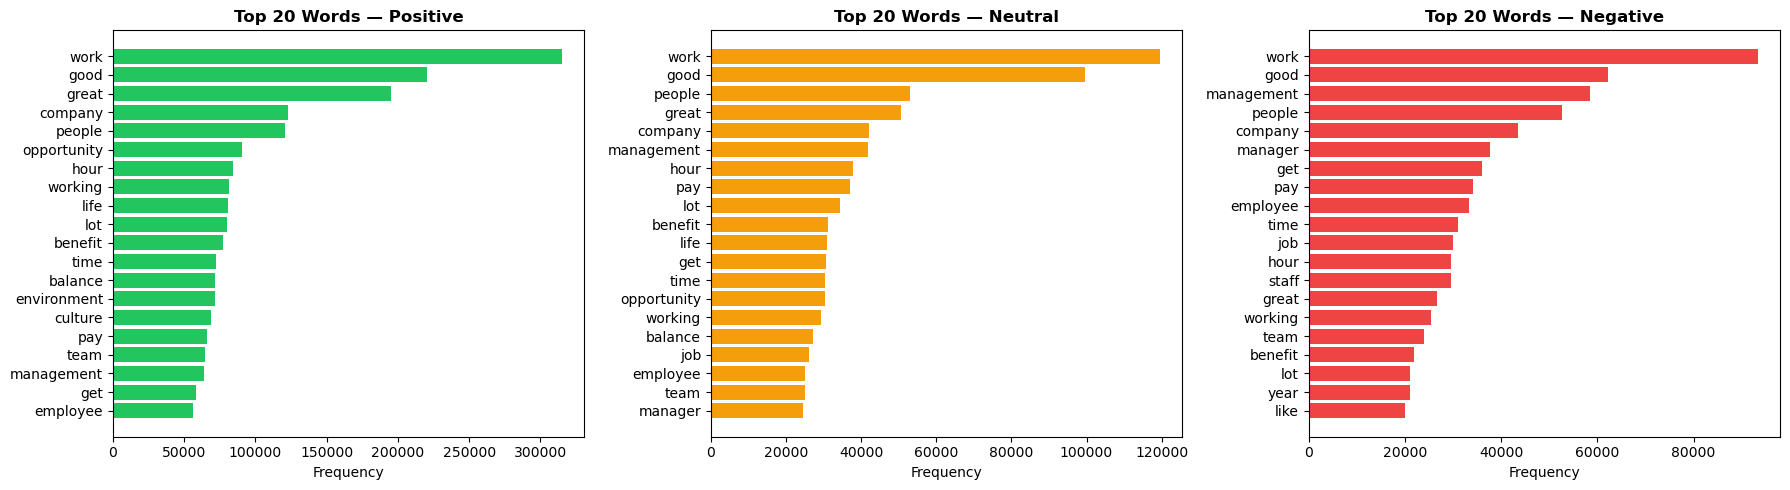

✅ Saved to assets/top_words.png


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'Positive': '#22c55e', 'Neutral': '#f59e0b', 'Negative': '#ef4444'}

for ax, sentiment in zip(axes, ['Positive', 'Neutral', 'Negative']):
    subset = df[df['sentiment'] == sentiment]['tokens']
    all_tokens = [t for tokens in subset for t in tokens]
    top20 = Counter(all_tokens).most_common(20)
    words, freqs = zip(*top20)
    ax.barh(words[::-1], freqs[::-1], color=colors[sentiment])
    ax.set_title(f'Top 20 Words — {sentiment}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('../assets/top_words.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved to assets/top_words.png')

## 10. Save Cleaned Dataset

In [24]:
# Keep only columns needed downstream
PROCESSED_PATH = '../data/processed/cleaned.csv'
save_cols = ['text', 'clean_text', 'sentiment', rating_col]
if 'date' in df.columns:
    save_cols.append('date')

df_clean = df[save_cols].copy()
df_clean.to_csv(PROCESSED_PATH, index=False)

print(f'✅ Saved {len(df_clean):,} rows → {PROCESSED_PATH}')
print(f'   Columns: {df_clean.columns.tolist()}')
print('\nReady for Notebook 03 — Classical Model')
df_clean.head(3)

✅ Saved 805,051 rows → ../data/processed/cleaned.csv
   Columns: ['text', 'clean_text', 'sentiment', 'overall_rating']

Ready for Notebook 03 — Classical Model


,text,clean_text,sentiment,overall_rating
0,Very friendly and welcoming to new staff. Easy...,friendly welcoming new staff easy going ethic ...,Negative,2
1,"Friendly, helpful and hard-working colleagues ...",friendly helpful hard working colleague poor s...,Negative,2
2,Easy to get the job even without experience in...,easy get job even without experience finance l...,Negative,1
